In [22]:
import math
import pickle

import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.ndimage import rotate
from scipy.ndimage import maximum_filter
from scipy.signal import convolve2d

from typing import List, Sequence, Tuple

In [23]:
# --------------------------------------------------
# Data
# --------------------------------------------------

LAYER_NAME = "d4"

TRAJECTORY_RESULTS_PATH = (
    r"C:\Users\ALL AtoZ\Desktop\2d_hippocampal_cells\2D-traj-results-training.pkl"
)

# --------------------------------------------------
# Analysis
# --------------------------------------------------

N_BINS = 40

GAUSSIAN_WINDOW = 9

GAUSSIAN_SIGMA = 3.0

THRESHOLD_K = 1.5

EPS = 1e-10

SKIP_TIMESTEPS = 50

BOUNDS = (0.0, 1.0, 0.0, 1.0)

In [24]:
def matlab_style_gauss2d(shape=(9,9), sigma=3.0):

    m, n = [(ss-1.)/2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x+y*y)/(2*sigma*sigma))

    h[h < np.finfo(h.dtype).eps*h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h

In [25]:
def occupancy_map_func(
    pos,
    reso=N_BINS//2,
    win_len=GAUSSIAN_WINDOW,
    sigma=GAUSSIAN_SIGMA,
):

    hist, _, _ = np.histogram2d(
        pos[:,0],
        pos[:,1],
        bins=reso*2,
    )

    gaussian = matlab_style_gauss2d(
        (win_len,win_len),
        sigma,
    )

    pos_prob = signal.convolve2d(
        gaussian,
        hist,
    )

    trim = win_len//2

    pos_prob = pos_prob[
        trim:-trim,
        trim:-trim,
    ]

    pos_prob /= np.nansum(pos_prob)

    return pos_prob

In [42]:
def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = 80,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
) -> Tuple[np.ndarray, List[float]]:
    mean_resp = np.mean(responses)
    std_resp = np.std(responses)
    thresh = mean_resp + (thresh_param * std_resp)
    firing_idx = np.flatnonzero(responses > thresh)

    xmin, xmax = float(np.min(pos[:, 0])), float(np.max(pos[:, 0]))
    ymin, ymax = float(np.min(pos[:, 1])), float(np.max(pos[:, 1]))

    x = np.linspace(xmin, xmax, res_param)
    y = np.linspace(ymin, ymax, res_param)
    firing_map = np.zeros((res_param, res_param), dtype=float)

    if firing_idx.size:
        firing_positions = pos[firing_idx, :2]
        firing_values = responses[firing_idx]

        for ii in range(len(firing_positions)):
            col = int(np.argmin(np.abs(firing_positions[ii, 0] - x)))
            row = int(np.argmin(np.abs(firing_positions[ii, 1] - y)))
            firing_map[row, col] = max(firing_values[ii], firing_map[row, col])

    if normalization == "occupancy" and occupancy_map is not None:
        occ = np.asarray(occupancy_map, dtype=float).copy()
        occ[occ == 0] = np.nan
        with np.errstate(divide="ignore", invalid="ignore"):
            firing_map = np.divide(
                firing_map,
                occ,
                out=np.zeros_like(firing_map, dtype=float),
                where=np.isfinite(occ) & (occ != 0),
            )
        firing_map = np.nan_to_num(firing_map, nan=0.0)
    else:
        max_value = float(np.nanmax(firing_map)) if firing_map.size else 0.0
        if max_value > 0:
            firing_map = firing_map / max_value

    gaussian = matlab_style_gauss2d(gaussian_shape, gaussian_sigma)
    spikes_smooth = signal.convolve2d(gaussian, firing_map)
    trim = int(gaussian_shape[0] // 2)
    spikes_smooth = spikes_smooth[trim:-trim, trim:-trim]
    extent = [xmin, xmax, ymin, ymax]
    return spikes_smooth, extent

In [43]:
def load_dataset(
    pkl_path,
    layer_name,
    skip_timesteps=SKIP_TIMESTEPS,
):
    """
    Load trajectory predictions and neural activations.

    Returns
    -------
    ground_truth : (n_traj, T, 2)
    prediction   : (n_traj, T, 2)
    positions    : (n_traj, T, 2)
    activations  : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])
    prediction = np.asarray(data["prediction"])
    activations = np.asarray(data[layer_name])

    # We analyse predicted positions
    positions = prediction.copy()

    if skip_timesteps > 0:

        ground_truth = ground_truth[:, skip_timesteps:, :]
        prediction = prediction[:, skip_timesteps:, :]
        positions = positions[:, skip_timesteps:, :]
        activations = activations[:, skip_timesteps:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [44]:
def concatenate_trajectories(
    positions,
    activations,
    ground_truth,
    prediction,
    trajectory_ids,
):
    """
    Concatenate multiple trajectories into one long trajectory.
    """

    return {

        "positions": np.concatenate(
            [positions[i] for i in trajectory_ids],
            axis=0,
        ),

        "activations": np.concatenate(
            [activations[i] for i in trajectory_ids],
            axis=0,
        ),

        "ground_truth": np.concatenate(
            [ground_truth[i] for i in trajectory_ids],
            axis=0,
        ),

        "prediction": np.concatenate(
            [prediction[i] for i in trajectory_ids],
            axis=0,
        ),
    }

In [45]:
EPS = 1e-10

def spatial_information(
    rate_map,
    occupancy_map,
):
    """
    Spatial Information (Skaggs et al., 1993)

    Parameters
    ----------
    rate_map : (N,N)
        Smoothed firing-rate map

    occupancy_map : (N,N)
        Probability occupancy map (sum = 1)

    Returns
    -------
    Spatial Information (bits/spike)
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
        &
        (rate_map > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    if mean_rate < EPS:
        return np.nan

    ratio = r / mean_rate

    SI = np.sum(
        p *
        ratio *
        np.log2(ratio)
    )

    return SI

In [46]:
def sparsity(
    rate_map,
    occupancy_map,
):
    """
    Population Sparsity
    """

    occ = occupancy_map.astype(float)

    occ = occ / np.sum(occ)

    valid = (
        (~np.isnan(rate_map))
        &
        (occ > 0)
    )

    if valid.sum() == 0:
        return np.nan

    p = occ[valid]

    r = rate_map[valid]

    mean_rate = np.sum(
        p * r
    )

    mean_rate_sq = np.sum(
        p * r**2
    )

    if mean_rate_sq < EPS:
        return np.nan

    return (mean_rate**2) / mean_rate_sq

In [47]:
ground_truth, prediction, positions, activations = load_dataset(
    TRAJECTORY_RESULTS_PATH,
    LAYER_NAME,
)

print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [48]:
# ============================================================
# PLACE CELL ANALYSIS — RESET
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ------------------------------------------------------------
# Spatial resolution
# ------------------------------------------------------------

N_BINS = 40

# Environment boundaries
X_MIN, X_MAX = 0.0, 1.0
Y_MIN, Y_MAX = 0.0, 1.0

BOUNDS = (X_MIN, X_MAX, Y_MIN, Y_MAX)


# ------------------------------------------------------------
# Firing-rate parameters
# ------------------------------------------------------------

THRESHOLD_K = 1.5

GAUSSIAN_WINDOW = 9
GAUSSIAN_SIGMA = 3.0

EPS = 1e-10


# ------------------------------------------------------------
# Check data
# ------------------------------------------------------------

print("Ground truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

print("\nN_BINS:", N_BINS)
print("Bounds:", BOUNDS)

Ground truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)

N_BINS: 40
Bounds: (0.0, 1.0, 0.0, 1.0)


In [49]:
# ============================================================
# RANDOM SAMPLING CONVERGENCE
# ============================================================

N_RANDOM_TRIALS = 100
MAX_TRAJECTORIES = 10

rng = np.random.default_rng(42)

coverage_all = np.zeros(
    (N_RANDOM_TRIALS, MAX_TRAJECTORIES)
)

for trial in range(N_RANDOM_TRIALS):

    # Randomly choose 10 unique trajectories
    random_traj = rng.choice(
        len(positions),
        size=MAX_TRAJECTORIES,
        replace=False
    )

    cumulative_mask = np.zeros(
        (N_BINS, N_BINS),
        dtype=bool
    )

    for n in range(MAX_TRAJECTORIES):

        traj_id = random_traj[n]
        traj = positions[traj_id]

        traj_counts, _, _ = np.histogram2d(
            traj[:, 0],
            traj[:, 1],
            bins=[x_edges, y_edges]
        )

        # Add trajectory's visited bins
        cumulative_mask |= traj_counts > 0

        # Compare against reference environment
        covered = (
            cumulative_mask &
            environment_mask
        )

        coverage_all[trial, n] = (
            covered.sum()
            / n_environment_bins
        )


# ============================================================
# Calculate statistics
# ============================================================

mean_coverage = coverage_all.mean(axis=0)

std_coverage = coverage_all.std(axis=0)

lower_coverage = np.percentile(
    coverage_all,
    2.5,
    axis=0
)

upper_coverage = np.percentile(
    coverage_all,
    97.5,
    axis=0
)


# ============================================================
# Print results
# ============================================================

print("Random sampling convergence")
print("=" * 45)

for n in range(MAX_TRAJECTORIES):

    print(
        f"{n+1:2d} trajectories | "
        f"mean = {mean_coverage[n]*100:6.2f}% | "
        f"SD = {std_coverage[n]*100:5.2f}% | "
        f"95% CI = "
        f"{lower_coverage[n]*100:5.2f}%–"
        f"{upper_coverage[n]*100:5.2f}%"
    )

NameError: name 'x_edges' is not defined

In [ ]:
# ============================================================
# CONVERGENCE PLOT
# ============================================================

x = np.arange(
    1,
    MAX_TRAJECTORIES + 1
)

plt.figure(figsize=(8, 6))

plt.plot(
    x,
    mean_coverage * 100,
    marker="o",
    linewidth=2,
    label="Mean coverage"
)

plt.fill_between(
    x,
    lower_coverage * 100,
    upper_coverage * 100,
    alpha=0.2,
    label="95% range"
)

plt.xlabel("Number of trajectories")
plt.ylabel("Environment coverage (%)")

plt.title(
    f"Spatial Coverage Convergence "
    f"({N_RANDOM_TRIALS} random samples)"
)

plt.xticks(x)

plt.ylim(0, 100)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

NameError: name 'mean_coverage' is not defined

<Figure size 800x600 with 0 Axes>

In [35]:
# ============================================================
# GREEDY SELECTION OF 10 TRAJECTORIES FOR MAXIMUM COVERAGE
# ============================================================

N_SELECT = 10

# ------------------------------------------------------------
# 1. Precompute spatial-bin mask for every trajectory
# ------------------------------------------------------------

trajectory_masks = []

for traj_id in range(len(positions)):

    traj = positions[traj_id]

    counts, _, _ = np.histogram2d(
        traj[:, 0],
        traj[:, 1],
        bins=[x_edges, y_edges]
    )

    trajectory_masks.append(counts > 0)

trajectory_masks = np.array(trajectory_masks)

print("Trajectory masks:", trajectory_masks.shape)


# ------------------------------------------------------------
# 2. Greedy selection
# ------------------------------------------------------------

selected_traj = []
cumulative_mask = np.zeros(
    (N_BINS, N_BINS),
    dtype=bool
)

coverage_values = []

remaining = set(range(len(positions)))

for step in range(N_SELECT):

    best_traj = None
    best_new_bins = -1

    # Find trajectory adding the most previously uncovered bins
    for traj_id in remaining:

        candidate_mask = trajectory_masks[traj_id]

        new_bins = (
            candidate_mask &
            environment_mask &
            ~cumulative_mask
        ).sum()

        if new_bins > best_new_bins:

            best_new_bins = new_bins
            best_traj = traj_id

    # Add best trajectory
    selected_traj.append(best_traj)

    cumulative_mask |= trajectory_masks[best_traj]

    remaining.remove(best_traj)

    # Calculate coverage
    covered = (
        cumulative_mask &
        environment_mask
    )

    coverage = (
        covered.sum()
        / n_environment_bins
    )

    coverage_values.append(coverage)

    print(
        f"{step + 1:2d} trajectories | "
        f"added trajectory {best_traj:3d} | "
        f"new bins = {best_new_bins:4d} | "
        f"coverage = {coverage * 100:6.2f}%"
    )


# ------------------------------------------------------------
# 3. Final result
# ------------------------------------------------------------

print("\n========================================")
print("FINAL SELECTED TRAJECTORIES")
print("========================================")

print(selected_traj)

print(
    f"\nFinal coverage: "
    f"{coverage_values[-1] * 100:.2f}%"
)

NameError: name 'x_edges' is not defined

In [36]:
# ============================================================
# OCCUPANCY MAP FOR EACH TRAJECTORY
# ============================================================

occupancy_counts = np.zeros(
    (len(selected_traj), N_BINS, N_BINS)
)

occupancy_probability = np.zeros_like(
    occupancy_counts
)

for t, traj_id in enumerate(selected_traj):

    pos = positions[traj_id]

    counts, _, _ = np.histogram2d(
        pos[:, 0],
        pos[:, 1],
        bins=[x_edges, y_edges]
    )

    occupancy_counts[t] = counts

    total = counts.sum()

    if total > 0:
        occupancy_probability[t] = counts / total


print("Occupancy counts shape:")
print(occupancy_counts.shape)

print("\nOccupancy probability shape:")
print(occupancy_probability.shape) 

NameError: name 'x_edges' is not defined

In [37]:
# ============================================================
# FROZEN TRAJECTORIES
# ============================================================

selected_traj = [
    342,
    397,
    56,
    234,
    220,
    30,
    343,
    456,
    201,
    378
]

N_TRAJECTORIES = len(selected_traj)
N_NEURONS = activations.shape[2]

print("Selected trajectories:")
print(selected_traj)

print("\nNumber of trajectories:", N_TRAJECTORIES)
print("Number of neurons:", N_NEURONS)

Selected trajectories:
[342, 397, 56, 234, 220, 30, 343, 456, 201, 378]

Number of trajectories: 10
Number of neurons: 100


In [41]:
# ============================================================
# INDIVIDUAL TRAJECTORY × NEURON ANALYSIS
# ============================================================

N_NEURONS = activations.shape[2]
N_TRAJECTORIES = len(selected_traj)

print("Neurons:", N_NEURONS)
print("Trajectories:", N_TRAJECTORIES)


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

rate_maps = np.full(
    (
        N_TRAJECTORIES,
        N_NEURONS,
        N_BINS,
        N_BINS
    ),
    np.nan
)


# ------------------------------------------------------------
# Calculate independently
# ------------------------------------------------------------

for t, traj_id in enumerate(selected_traj):

    # Position for THIS trajectory only
    pos = positions[traj_id]

    for neuron in range(N_NEURONS):

        # Response of THIS neuron during THIS trajectory
        responses = activations[
            traj_id,
            :,
            neuron
        ]

        # Your existing firing-rate function
        rate_maps[t, neuron] = build_firing_rate_map(
            response=responses,
            pos=pos
        )


print("\nRate maps:")
print(rate_maps.shape)

Neurons: 100
Trajectories: 10


TypeError: build_firing_rate_map() got an unexpected keyword argument 'response'. Did you mean 'responses'?

In [40]:

# ============================================================
# OCCUPANCY MAPS — ONE PER TRAJECTORY
# ============================================================

occupancy_maps = np.zeros(
    (
        N_TRAJECTORIES,
        N_BINS,
        N_BINS
    )
)

for t, traj_id in enumerate(selected_traj):

    pos = positions[traj_id]

    occupancy_maps[t] = occupancy_map_func(
        pos=pos
    )


print("Occupancy maps:")
print(occupancy_maps.shape)

Occupancy maps:
(10, 40, 40)


In [18]:
# ============================================================
# SPATIAL INFORMATION + SPARSITY
# ============================================================

spatial_information_values = np.full(
    (
        N_TRAJECTORIES,
        N_NEURONS
    ),
    np.nan
)

sparsity_values = np.full(
    (
        N_TRAJECTORIES,
        N_NEURONS
    ),
    np.nan
)


# ------------------------------------------------------------
# Calculate independently
# ------------------------------------------------------------

for t in range(N_TRAJECTORIES):

    occupancy = occupancy_maps[t]

    for neuron in range(N_NEURONS):

        rate_map = rate_maps[
            t,
            neuron
        ]

        # SI
        spatial_information_values[
            t,
            neuron
        ] = spatial_information(
            rate_map,
            occupancy
        )

        # Sparsity
        sparsity_values[
            t,
            neuron
        ] = sparsity(
            rate_map,
            occupancy
        )


print("SI shape:")
print(spatial_information_values.shape)

print("\nSparsity shape:")
print(sparsity_values.shape)

SI shape:
(10, 100)

Sparsity shape:
(10, 100)


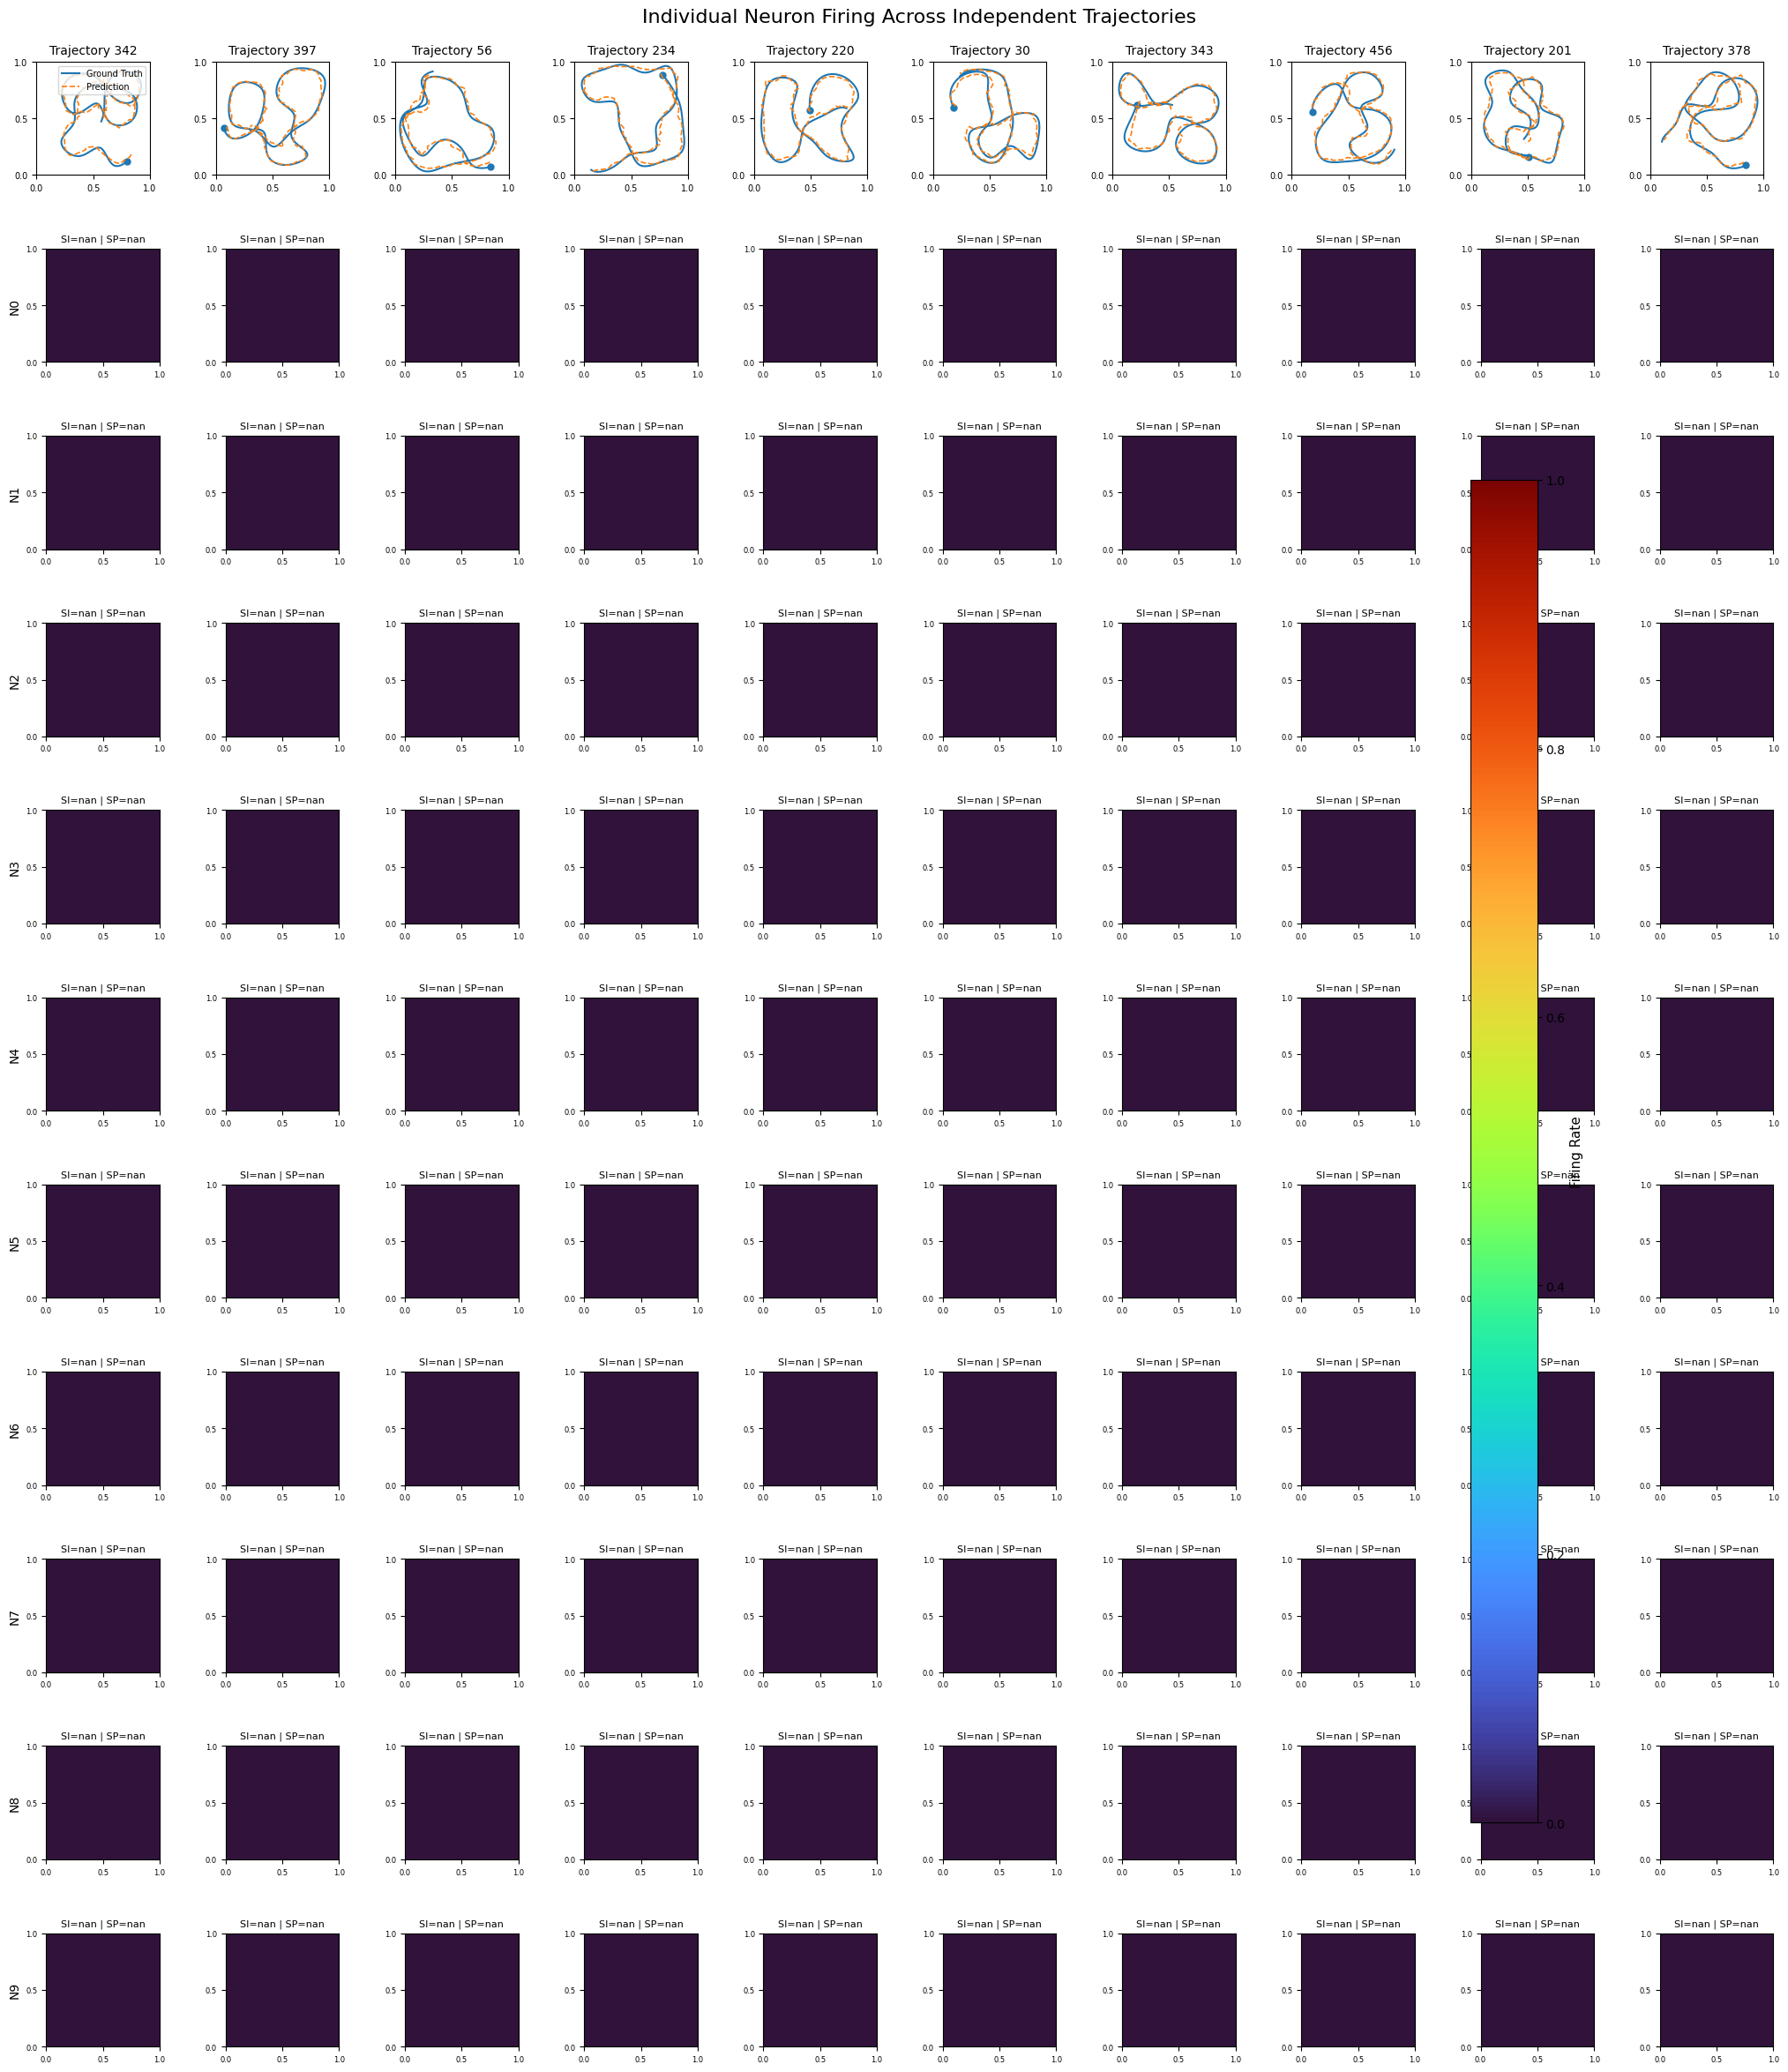

In [21]:
# ============================================================
# TRAJECTORY + INDIVIDUAL FIRING-RATE MAPS
#
# Columns = trajectories
# Top row  = Ground Truth vs Prediction
# Other rows = neurons
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

neurons_to_plot = list(range(10))

N_TRAJECTORIES = len(selected_traj)
N_NEURONS_PLOT = len(neurons_to_plot)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    N_NEURONS_PLOT + 1,
    N_TRAJECTORIES,
    figsize=(22, 2.2 * (N_NEURONS_PLOT + 1))
)

axes = np.asarray(axes)

if axes.ndim == 1:
    axes = axes.reshape(
        N_NEURONS_PLOT + 1,
        N_TRAJECTORIES
    )


# ============================================================
# TOP ROW — TRAJECTORIES
# ============================================================

for col, traj_id in enumerate(selected_traj):

    ax = axes[0, col]

    # Ground truth
    gt = ground_truth[traj_id]

    # Prediction
    pred = prediction[traj_id]

    ax.plot(
        gt[:, 0],
        gt[:, 1],
        linewidth=1.5,
        label="Ground Truth"
    )

    ax.plot(
        pred[:, 0],
        pred[:, 1],
        linewidth=1.2,
        linestyle="--",
        label="Prediction"
    )

    # Start point
    ax.scatter(
        gt[0, 0],
        gt[0, 1],
        s=25,
        marker="o"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    ax.set_title(
        f"Trajectory {traj_id}",
        fontsize=10
    )

    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

    ax.tick_params(
        labelsize=7
    )


# ============================================================
# COMMON FIRING-RATE SCALE
# ============================================================

displayed_rates = rate_maps[
    :,
    neurons_to_plot
]

valid_rates = displayed_rates[
    np.isfinite(displayed_rates)
    &
    (displayed_rates > 0)
]

if len(valid_rates) > 0:
    vmax = np.percentile(
        valid_rates,
        99
    )
else:
    vmax = 1.0


# ============================================================
# FIRING-RATE MAPS
# ============================================================

for row, neuron in enumerate(
    neurons_to_plot,
    start=1
):

    for col, traj_id in enumerate(
        selected_traj
    ):

        ax = axes[row, col]

        rate_map = rate_maps[
            col,
            neuron
        ].copy()

        rate_map = np.nan_to_num(
            rate_map,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        im = ax.imshow(
            rate_map.T,
            origin="lower",
            extent=[0, 1, 0, 1],
            cmap="turbo",
            aspect="equal",
            interpolation="bilinear",
            vmin=0,
            vmax=vmax
        )

        # SI + sparsity
        si = spatial_information_values[
            col,
            neuron
        ]

        sp = sparsity_values[
            col,
            neuron
        ]

        ax.set_title(
            f"SI={si:.2f} | SP={sp:.2f}",
            fontsize=8
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])

        ax.tick_params(
            labelsize=6
        )

    # Neuron label
    axes[row, 0].set_ylabel(
        f"N{neuron}",
        fontsize=10
    )


# ============================================================
# TRAJECTORY LEGEND
# ============================================================

axes[0, 0].legend(
    fontsize=7,
    loc="upper right"
)


# ============================================================
# FIRING-RATE COLORBAR
# ONLY SPAN THE FIRING-RATE-MAP ROWS
# ============================================================

firing_axes = axes[1:, :].ravel()

cbar = fig.colorbar(
    im,
    ax=firing_axes,
    shrink=0.90,
    pad=0.015
)

cbar.set_label(
    "Firing Rate",
    fontsize=11
)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Individual Neuron Firing Across Independent Trajectories",
    fontsize=16,
    y=0.995
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.04,
    right=0.94,
    bottom=0.04,
    top=0.97,
    wspace=0.35,
    hspace=0.65
)

plt.show()